# Ejercicio 5 - Punto libre: comparación de funciones de activación


## Tema elegido
Comparación del comportamiento de tres funciones de activación (**sigmoide, tanh y ReLU**) en una red neuronal de dos capas ocultas.

La elección se relaciona directamente con el contenido del capítulo: la función de activación introduce la no linealidad de la red y permite que una red con varias capas represente relaciones más complejas.

In [1]:
# Si es necesario:
# !pip install tensorflow scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

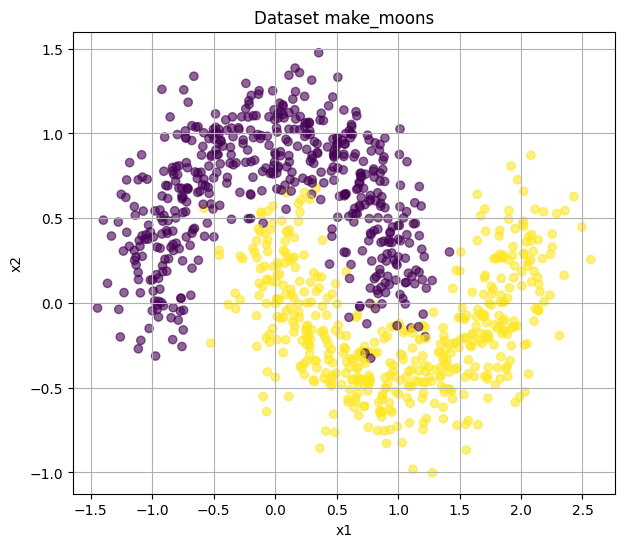

In [2]:
# Dataset no lineal de dos clases
X, y = make_moons(
    n_samples=1000,
    noise=0.20,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.6)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset make_moons")
plt.grid(True)
plt.show()

## Modelos

Los tres modelos tienen exactamente la misma topología:

- 2 entradas
- 16 neuronas en la primera capa oculta
- 8 neuronas en la segunda capa oculta
- 1 salida sigmoidal

La única diferencia es la función de activación utilizada en las dos capas ocultas.

In [3]:
def construir_modelo(activacion):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(16, activation=activacion),
        tf.keras.layers.Dense(8, activation=activacion),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

activaciones = ["sigmoid", "tanh", "relu"]
modelos = {}
historias = {}
resultados = []

for act in activaciones:
    tf.random.set_seed(42)
    modelo = construir_modelo(act)

    hist = modelo.fit(
        X_train_s, y_train,
        validation_split=0.20,
        epochs=150,
        batch_size=32,
        verbose=0
    )

    prob = modelo.predict(X_test_s, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    acc = accuracy_score(y_test, pred)

    modelos[act] = modelo
    historias[act] = hist
    resultados.append({
        "Activación": act,
        "Precisión prueba": acc,
        "Pérdida final entrenamiento": hist.history["loss"][-1],
        "Precisión final entrenamiento": hist.history["accuracy"][-1]
    })

resultados_df = pd.DataFrame(resultados)
display(resultados_df)

,Activación,Precisión prueba,Pérdida final entrenamiento,Precisión final entrenamiento
0,sigmoid,0.988,0.087640,0.968333
1,tanh,0.992,0.065437,0.973333
2,relu,0.988,0.053647,0.975000


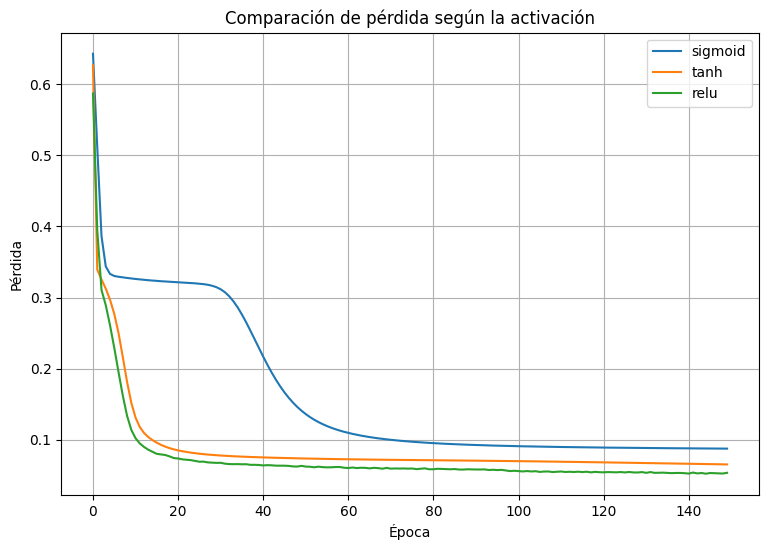

In [4]:
# Comparar las curvas de pérdida
plt.figure(figsize=(9,6))
for act in activaciones:
    plt.plot(historias[act].history["loss"], label=act)

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Comparación de pérdida según la activación")
plt.legend()
plt.grid(True)
plt.show()

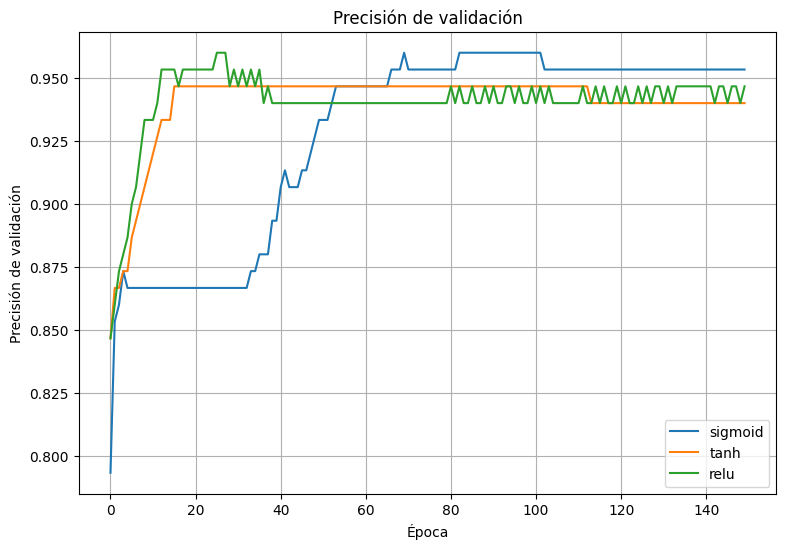

In [5]:
# Comparar la precisión de validación
plt.figure(figsize=(9,6))
for act in activaciones:
    plt.plot(historias[act].history["val_accuracy"], label=act)

plt.xlabel("Época")
plt.ylabel("Precisión de validación")
plt.title("Precisión de validación")
plt.legend()
plt.grid(True)
plt.show()

## Interpretación

La sigmoide puede presentar saturación cuando sus entradas tienen magnitudes grandes, lo que puede dificultar el entrenamiento. La función tanh también puede saturarse, aunque está centrada alrededor de cero. ReLU evita parte de este problema y suele facilitar el entrenamiento de redes profundas.

La comparación experimental permite comprobar que la elección de la función de activación afecta tanto la velocidad de aprendizaje como el desempeño final, incluso cuando la topología y los demás hiperparámetros permanecen constantes.

## Conclusión

En este punto libre se comprobó experimentalmente la importancia de la función de activación. Las tres redes tienen la misma estructura, por lo que las diferencias observadas se atribuyen principalmente a la activación de las capas ocultas. El mejor modelo debe determinarse a partir de la precisión y de las curvas de entrenamiento/validación, no solamente de la pérdida final.